# Epsilon-free Composation
$X ∘ Y$* Producing a new WFST whose input is the input of $X$ and output is the output of $Y$, with weights equal to the semiring product of the two weights.

In [1]:
# Use semiring pkg and showing pkg
begin
    using Dioids
    using ShowDOT
    include("d://repos//FSM.jl//src//FSM.jl")
    showfst  = autoshow ∘ dot;
    showfsts = autoshow ∘ dots;
end

ShowDOT.autoshow ∘ Main.dots

a simple example

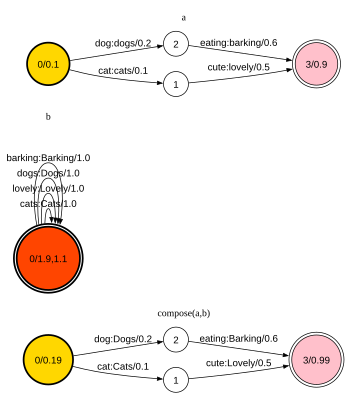

In [2]:
let 
    a = WFST();
    addarc(a, 0, 1, "cat",    "cats",    0.1)
    addarc(a, 1, 3, "cute",   "lovely",  0.5)
    addarc(a, 0, 2, "dog",    "dogs",    0.2)
    addarc(a, 2, 3, "eating", "barking", 0.6)
    addstart(a, 0, 0.1)
    addfinal(a, 3, 0.9)

    # Upper case for first letter
    b = WFST();
    addarc(b, 0, 0, "cats",    "Cats",    1.0)
    addarc(b, 0, 0, "lovely",  "Lovely",  1.0)
    addarc(b, 0, 0, "dogs",    "Dogs",    1.0)
    addarc(b, 0, 0, "barking", "Barking", 1.0)
    addstart(b, 0, 1.9)
    addfinal(b, 0, 1.1)

    c = compose(a,b)
    setdpi(50)
    showfsts([a,b,c], digits=2,
             labels=["a", "b", "compose(a,b)"],
             rankdir="LR")
end

a example from two papers: 
+ *Mehryar Mohri, Weighted Finite-State Transducer Algorithms An Overview*, Figure 1
+ *Mehryar Mohri, Weighted Automata Algorithms* : Fig. 6

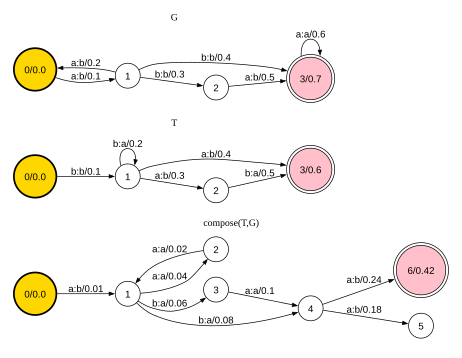

In [3]:
let
    T = WFST();
    addarc(T, "0 1 a:b/0.1")
    addarc(T, "1 0 a:b/0.2")
    addarc(T, "1 2 b:b/0.3")
    addarc(T, "1 3 b:b/0.4")
    addarc(T, "2 3 a:b/0.5")
    addarc(T, "3 3 a:a/0.6")
    addstart(T, 0, 0.0)
    addfinal(T, 3, 0.7)

    G = WFST();
    addarc(G, "0 1 b:b/0.1")
    addarc(G, "1 1 b:a/0.2")
    addarc(G, "1 2 a:b/0.3")
    addarc(G, "1 3 a:b/0.4")
    addarc(G, "2 3 b:a/0.5")
    addstart(G, 0, 0.0)
    addfinal(G, 3, 0.6)
    setdpi(50)
    showfsts([T, G, compose(T,G)], 
             labels=["G","T", "compose(T,G)"])
end

# General Composation with $\epsilon$
## $\epsilon$ 匹配滤波器设计
处理 ε-transitions, 以下两个FST使用 ε-free-compose 将失败 😭😭😭

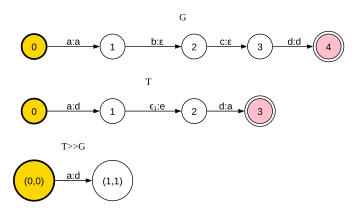

In [ ]:
let
    T = WFST();
    addarc(T, "0 1 a:a");addarc(T, "1 2 b:");addarc(T, "2 3 c:");addarc(T, "3 4 d:d")
    addstart(T, 0);addfinal(T, 4)

    G = WFST();
    addarc(G, "0 1 a:d");addarc(G, "1 2 ε₁:e");addarc(G, "2 3 d:a");
    addstart(G, 0);addfinal(G, 3)
    setdpi(50)
    showfsts([T, G, _compose(T,G)], labels=["G", "T", "T>>G"], keepone=false)
end

ε-free-compose 是在「二维网格」上走步：状态是 $(q₁, q₂)$，每一步必须同时消耗 T₁的一个输出符号和 T₂的一个输入符号，且两个符号相等，才能从一个格子走到下一个格子。这种情况下，任意两个状态之间，如果输入输出序列固定，路径是唯一对应的。但 ε（空符号）的语义是「不消耗或者不产出任何符号就能完成一次状态转移」，这就导致网格里多了两种合法走法：
+ **横向单步**：T₁走一条输出为 ε 的边，T₂原地不动
+ **纵向单步**：T₂走一条输入为 ε 的边，T₁原地不动
+ **对角线步**：T₁的输出 ε 和 T₂的输入 ε 刚好匹配，两边各走一步
  
如下图所示（为理论推导的图，ε-free-compose 算法无法得到下图结果），这三条路径对应的输入输出完全相同，但权重会被分别计算再求和, 对于**非幂等半环**（比如概率半环、log 半环），同一条路径的权重被重复累加，结果完全错误。这就是**路径多重性（path multiplicity）问题**：从同一个起点到同一个终点，会出现多条完全等价的带 ε 的路径（它们对应的输入、输出序列完全一样），但在组合后的自动机里被当成了不同的路径。
<div align="center">
  <img src="compose-eps.PNG" alt="3 way" width="300"/>
</div>

为了得到类似的图需要借助 ε-free-compose 算法与去自环操作，还需要假想输入FST与输出FST的每个状态上都有一条 ε:ε 边（为了横向、纵向单步移动的目的），即有例子
<div align="center">
  <img src="compose-eps-selfloop.PNG" alt="muti-ways" width="800"/>
</div>

代码为
```julia
begin
    T = WFST();
    addarc(T, "0 1 a:"); addarc(T, "1 2 b:"); addarc(T, "2 3 c:"); 
    addarc(T, "0 0 :"); addarc(T, "1 1 :");addarc(T, "2 2 :");addarc(T, "3 3 :");
    addstart(T, 0);addfinal(T, 3)

    G = WFST();
    addarc(G, "0 1 :e"); addarc(G, "1 2 :f"); addarc(G, "0 0 :");addarc(G, "1 1 :");addarc(G, "2 2 :");
    addstart(G, 0);addfinal(G, 2)
    
    C = rmselfloops(_compose(T,G))
    setdpi(70); showfst(C, keepone=false)
end
# 成图需要使用如下对齐方式才方方正正的好看
# {rank=same "(0,0)" "(0,1)" "(0,2)"}
# {rank=same "(1,0)" "(1,1)" "(1,2)"}
# {rank=same "(2,0)" "(2,1)" "(2,2)"}
# {rank=same "(3,0)" "(3,1)" "(3,2)"}
```

为了解决路径多重性问题，需要在所有等价的 epsilon 路径里，只保留唯一一条合法路径，把其余的全部过滤掉。解决思路就是对 ε 做分类，再用一个小型FST强制移动顺序以保证路径唯一，这里需要区别横向移动与纵向移动：
+ **横向移动**：T 的 ε 输出改为 ε2，G 的每个状态加 ε₂:ε 自环，这两种边组合起来就是 T 走一步而 G 不动
+ **纵向移动**：T 的每个状态加 ε:ε₁ 自环，G 的 ε 输入改为 ε₁，这两种边组合起来就是 T 不动而 G 走一步 

总而言之就是
+ T 的每个状态加 ε:ε₁ 自环，原本 ε 输出改为 ε₂
+ G 的每个状态加 ε₂:ε 自环，原本 ε 输入改为 ε₁

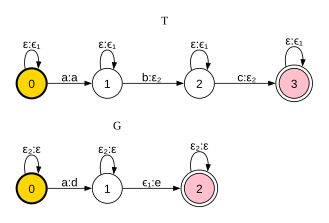

In [ ]:
begin
    T = WFST();
    addarc(T, "0 1 a:a"); 
    addarc(T, "1 2 b:ε₂"); 
    addarc(T, "2 3 c:ε₂");
    addarc(T, "0 0 ε:ε₁"); addarc(T, "1 1 ε:ε₁"); addarc(T, "2 2 ε:ε₁"); addarc(T, "3 3 ε:ε₁");
    addstart(T, 0); addfinal(T, 3)

    G = WFST();
    addarc(G, "0 1  a:d"); addarc(G, "1 2 ε₁:e");
    addarc(G, "0 0 ε₂:ε"); addarc(G, "1 1 ε₂:ε"); addarc(G, "2 2 ε₂:ε");
    addstart(G, 0); addfinal(G, 2)
    
    setdpi(60); showfsts([T, G], keepone=false, labels=["T", "G"])
end

空符号匹配语义
+ ⓟ─x:ε₂​─►ⓝ 匹配 ⓢ─ε₂:ε─►ⓢ, 简称 (ε₂,ε₂) 匹配，T₁走原生 ε，T₂不动，即横向移动 →
+ ⓢ─ε:ε₁─►​ⓢ 匹配 ⓤ─ε₁:x─►ⓥ, 简称 (ε₁,ε₁) 匹配，T₁不动, T₂走原生 ε，即纵向移动 ↓
+ ⓟ─x:ε₂​─►ⓝ 匹配 ⓤ─ε₁:x─►ⓥ, 简称 (ε₂,ε₁) 匹配，两边原生 ε 匹配，各走一步，即对角线移动 ↘
+ ⓟ─x:m─►ⓝ  匹配 ⓤ─m:x─►ⓥ, 真实符号匹配，两边各走一步
+ 禁止 ─ε:ε₁─►​ 与 ─ε₂:ε─► 互相匹配，即不允许两者都不动

接下来就是制定过滤规则，保证路径唯一，在最短路径框架下对角线就是最直接的最短路径，而通过 ε 拆解而成的多余路径在非幂等半环下显然不是，故而选择**对角线优先，单边集中**的原则，对角线上既可以是 (ε,ε) 匹配也可以是正常符号的匹配，在此原则下如下序列禁止
1. ❌ 禁止 (ε₁,ε₁) ⇃ 后面跟 (ε₂,ε₂) ⇀ 即先纵后横 ↳
2. ❌ 禁止 (ε₂,ε₂) ⇀ 后面跟 (ε₁,ε₁) ⇃ 即先横后纵 ↴
3. ❌ 禁止 (ε₁,ε₁) ⇃ 后面跟 (ε₂,ε₁) ↘ 即先纵后对角 ⇃↘
4. ❌ 禁止 (ε₂,ε₂) ⇀ 后面跟 (ε₂,ε₁) ↘ 即先横再对角 ⇀↘

然后对角可用跟任何单边结合，即 (↘⇀) (↘⇃) (↘↘), 没有对角也可以一直走单边, 这套规则可以保证任两个状态之间，有且仅有一条合法的 epsilon 路径。接下来把规则编码成有限状态机，不妨令 $a = (ε₁,ε₁), \ b = (ε₂,ε₂), \ c = (ε₂,ε₁), \ x = ({\rm x},{\rm x})$ 为任意正常非空匹配，那么不能允许的序列集合本身就可以表示成正则语言状态机的形式 $A = σ^* (ab + ba + ac + bc) σ^*$, 其中 $σ = \{a,b,c,x\}$, 通过确定化 A 然后再取其补集就能得到滤波器FST, 如下

<div align="center">
  <img src="eps-matching-filter-evolution.PNG" alt="ϵ-matching-filter-evolution" width="750"/>
</div>

去掉无效状态即得如下 ε-matching-filter
<div align="center">
  <img src="eps-matching-filter.PNG" alt="ϵ-matching-filter" width="250"/>
</div>
图中的 x 为第一个FST的输出与第二个FST的输入符号的交集中的任意一个符号。如下代码通过两次朴素的 epsilon-free-compose 实现统一的复合算法。

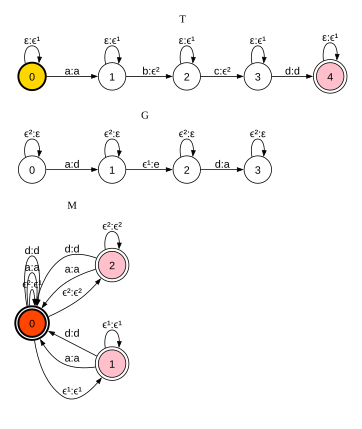

In [10]:
let
    T = WFST();
    addarc(T, "0 1 a:a")
    addarc(T, "1 2 b:")
    addarc(T, "2 3 c:")
    addarc(T, "3 4 d:d")
    addstart(T, 0);addfinal(T, 4)

    G = WFST();
    addarc(G, "0 1 a:d")
    addarc(G, "1 2 :e")
    addarc(G, "2 3 d:a")

    M = epsmatcher(T, G)
    R = matchcompose(T, G)
    setdpi(55); showfsts([T, G, M, R], labels=["T", "G", "M", "T >> M >> G"], keepone=false)
end

而两次 epsilon-free-compose 刚好是三个FST的复合，也称为3路复合。

## 3-way compose
### 3-way-epsilon-free-compose
用两次 epsilon-free-compose 复合三个FST即  $T = T₁ \ ◦ T₂ \ ◦ \ T₃$ 的算法复杂度为 $|T₁|*|T₂|*|T₃|$, 现在介绍一种更高效的 3-way-epsilon-free-compose 复合算法, 算法核心思路就是在每次复合 T₁ T₃ 边的时候，在 T₂ 中找匹配边。

<div align="center">
  <img src="compose-3-way.PNG" alt="3-way-compose" width="750"/>
</div>

这样在使用 ε-matching-filter 来复合两个含有 ε 的 FST 时，就无需使用两次 ε-free-compose 算法，而是直接使用一次 3-way-ε-free-compose 复合算法。

### 3-way-epsilon-compose
#### 背景：从二维网格到三维立方体
3路复合用原则上是用来加速两次 ε-free-compose 算法的，但是如果三个 FST 本身也有 ε 呢？仍然会遇到多路径问题，2-way-compose 是在「二维网格」上走步：状态是 $(q₁, q₂)$, 到了 3-way-compose 就是在「三维网格」上走步：状态是 $(q₁, q₂, q₃)$，二维中冗余路径较少，但是在三维中冗余数量很多，例如全 epsilon 边的话，从一个对角走到下一个对角共13种：
+ 一步单轴加平面共9种：
  + 先 x 轴再 yz 平面上的三种走法：y轴z轴, z轴y轴, yz对角；
  + 先 y 轴再 xz 平面上的三种走法：x轴z轴, z轴x轴, xz对角；
  + 先 z 轴再 xy 平面上的三种走法：x轴y轴, y轴x轴, xy对角；
+ 先对角再轴线共3种：
  + 先 xy 对角再走 z 轴；
  + 先 yz 对角再走 x 轴；
  + 先 xz 对角再走 y 轴
+ 直接走三维对角线，一步到位

<div align="center">
  <img src="cubic13.svg" alt="ϵ-matching-filter" width="1800"/>
</div>

维度越高，冗余路径数量爆炸得越厉害。如果不做过滤，非幂等半环的结果会完全错误，同时状态数也会疯狂膨胀。有必要给三维立方体里的走路定规矩，保证任意两点之间**有且仅有一条合法的 epsilon 路径**。
#### 统一语言：移动用三元组表达
先把所有可能的移动，统一编码成一个三元组 (a, b, c)，每个位置对应一台机器的动作：

- **0**：这台机器原地不动
- **1**：这台机器走一步 epsilon 转移
- **x**：这台机器走一步**真实符号**（非 epsilon），并且和相邻机器匹配上了

例如
+ (1, 1, 1) 三台机器各走一步 epsilon，互相匹配（三维对角线）
+ (0, 1, 1) T₁ 不动, T₂ T₃ 各走一步 epsilon 并匹配（先平面对角线再轴向）
+ (0, 0, 1) T₁ T₂ 不动, T₃ 走一步 epsilon 
+ (x, x, 0) T₁ T₂ 匹配到正常符号，T₃ 不动
+ (x, x, x) T₁ T₂ T₃ 一起匹配到正常符号

#### 过滤规则设计
滤波器的设计的总原则就是最短路径，这和二维情况是一致。实操即：匹配优先（含对角的优先）早动早结束，不回头。以下三条具体的禁令，只要在序列中出现则直接判定为非法路径过滤掉。
+ **停下就别再动 epsilon 了**，任意一台机器，如果上一步是 0 即没动，下一步就不能变为 1 即走 ε，通俗说就是：要走 ε 就趁早走，不能走一步歇一步、歇一步走一步。这条规则保证了每台机器的 ε 移动都是连续的不会断断续续，比如某台机器的合法序列只能是 11000，不能是10100。
+ **真匹配要趁早**，如果最终要做真实符号匹配，那就早做，别先慢悠悠走一堆 ε 再回来匹配。匹配永远比单边 ε 优先级高。这是最短路径准则决定的。例如不允许 (0,0,1)⋅(x,x,1) ，因为 (x,x,1)⋅(0,0,1) 可以更早匹配，也不允许 (0,0,1)⋅(x,x,0) 这种匹配顺序，因为有更短的匹配 (x,x,1) 
+ **禁止原地不动**，不允许出现 (0,0,0) 这种三元组，这代表三个机器都没动。

根据「匹配优先、能一起走就一起走」的原则，唯一合法的走法是：先满维对角线 → 再降维对角线 → 最后单轴走。拿纯 epsilon 例子验证：从 (0,0,0) 到 (1,1,1)，按规则只能一步走到 (1,1,1)。再举个复杂点例子，从 (0,0,0) 到 (2,5,6)，即 T₁ 走 2 步 ε，T₂ 走 5 步 ε，T₃ 走 6 步 ε，唯一合法路径是：
+ 先走2步(1,1,1), 剩余(0,3,4)=(2,5,6)-(2,2,2), 把最少的 T₁ 先用完
+ 再走3步(0,1,1), 剩余(0,0,1)=(0,3,4)-(0,3,3), 把剩下的 T₂ 用完
+ 再走1步(0,0,1), 即只剩下 T₃ 自己走

一旦遇到真实标签就代表这一段 ε 路径结束了，滤波器该退回初始状态了，下一段 ε 路径重新按规矩来。